# H&M Two-Tower Retrieval Model

## Architecture

```
──────────────────────────────── USER TOWER ────────────────────────────────

 past 128 orders (SEQ_LEN)
 each order = article categoricals + transaction features
        │
        ▼
 ┌─────────────────────────────────────────────────────┐
 │  SequenceEncoder                                    │
 │                                                     │
 │  for each of 128 history steps:                     │
 │    ItemTower(article) → 512-dim  ─┐                 │
 │    price_bucket       →   8-dim   │                 │
 │    sales_channel      →   1-dim   ├─ cat → 533-dim  │
 │    time_delta         →   4-dim   │                 │
 │    season sin/cos     →   8-dim  ─┘                 │
 │         │                                           │
 │    Linear(533 → 128) + positional embedding         │
 │         │                                           │
 │    TransformerEncoder (2 layers, 4 heads)           │
 │         │                                           │
 │    last token hidden state → 128-dim                │
 └─────────────────────────────────────────────────────┘
        │
        ├── customer_encoded  → 64-dim ─┐
        ├── FN, Active        →  2-dim  │
        ├── club_member       →  8-dim  ├─ cat → 218-dim → MLP → 512-dim L2-norm
        ├── fashion_news      →  8-dim  │                  (user embedding)
        └── age_bucket        →  8-dim ─┘


──────────────────────────────── ITEM TOWER ────────────────────────────────

 target article
        │
        ├── product_type      → 16-dim ─┐
        ├── appearance        →  8-dim  │
        ├── colour            → 16-dim  │
        ├── index_group       →  8-dim  ├─ cat → 456-dim → MLP → 512-dim L2-norm
        ├── section           → 16-dim  │                  (item embedding)
        ├── garment_group     →  8-dim  │
        └── text embedding    → 384-dim ┘
             (all-MiniLM-L6-v2, frozen)


─────────────────────────── WEIGHT SHARING ─────────────────────────────────

 ItemTower weights are SHARED between SequenceEncoder (history items)
 and the target item pass — history and target live in the same 512-dim space.
 text_embeddings stored as GPU buffer; indexed by article_encoded directly.


────────────────────────────────── LOSS ────────────────────────────────────

 logits = temperature × user_emb @ item_emb.T        (B × B matrix)
 InfoNCE = symmetric cross-entropy (diagonal = true pairs, rest = negatives)
 temperature = exp(logit_scale) — learnable scalar, initialized at exp(0)=1.0
 Initial loss ≈ ln(BATCH_SIZE) = ln(1024) ≈ 6.93  ← random baseline


─────────────────────────────── RETRIEVAL ──────────────────────────────────

 FAISS IndexFlatIP over active articles (sold in last 6 weeks of training).
 Inner product on L2-normalized vectors = cosine similarity.
```

---

## Hyperparameters

| Group | Parameter | Value | Notes |
|---|---|---|---|
| Sequence | `SEQ_LEN` | 128 | History window; must match at training and inference |
| Training | `BATCH_SIZE` | 1024 | Also = number of in-batch negatives per InfoNCE step |
| Training | `NUM_EPOCHS` | 10 | |
| Training | `LR` | 1e-3 | Peak learning rate for OneCycleLR |
| Training | `WEIGHT_DECAY` | 1e-4 | Applied to all params except biases, LayerNorm, logit_scale |
| Training | `WARMUP_STEPS` | 300 | Linear warmup steps at start of OneCycleLR |
| Training | `LOG_EVERY` | 200 | Print loss + temperature every N steps |
| Transformer | `TRANSFORMER_DIM` | 128 | Hidden size of TransformerEncoder |
| Transformer | `TRANSFORMER_HEADS` | 4 | Attention heads (head_dim = 32) |
| Transformer | `TRANSFORMER_LAYERS` | 2 | Number of encoder layers |
| Embeddings | `FINAL_DIM` | 512 | Joint user/item embedding space; FAISS index dimension |
| Embeddings | `TEXT_DIM` | 384 | all-MiniLM-L6-v2 output dimension |
| Embeddings | `ITEM_HIDDEN` | 256 | ItemTower MLP hidden dim |
| Embeddings | `USER_HIDDEN` | 256 | UserTower MLP hidden dim |

---

## Optimizer & Scheduler

**AdamW** with two parameter groups:
- Weight decay (`1e-4`) applied to all parameters except biases, LayerNorm weights, and `logit_scale`
- No weight decay on the above (prevents penalizing scale/shift parameters)

**OneCycleLR**: linear warmup for `WARMUP_STEPS / total_steps` fraction of training, then cosine annealing to zero. Stepped every training step (not epoch).

**Gradient clipping**: `max_norm=1.0` applied before every optimizer step to prevent gradient explosion from the B×T ItemTower calls in SequenceEncoder.

---

## Dataset — `HMRetrievalDataset`

One sample = one `(customer, target_article)` positive pair generated by sliding over each user's transaction history.

**Memory-efficient design:**
- Per-user sequences stored as compact numpy arrays (~350MB total for 96K users) — not as Python lists
- Training pairs stored as `(user_id, target_position)` integer pairs — no list-of-lists
- `max_targets_per_user=100`: caps how many pairs are sampled per user so high-activity users don't dominate; the last 100 purchases are used as targets
- The full transactions DataFrame is never stored as an instance variable

**Sequence packing (`_pack_seq`):**
- Takes the `end` index as the target position; uses `[end-128 : end]` as history
- Left-pads with zeros if the user has fewer than 128 prior purchases
- `padding_mask[j] = True` marks padded slots — ignored by the Transformer

---

## Evaluation

**Active articles**: only articles sold within 6 weeks of the Sep 8, 2020 training cutoff are added to the FAISS catalog. ARCHIVED items excluded at inference, not during training.

**FAISS IndexFlatIP**: exact inner product search. Since all embeddings are L2-normalized, this equals cosine similarity. No approximation.

**Recall@K**: fraction of a user's ground-truth purchases (Sep 9–15 test week) that appear in the top-K retrieved candidates. Averaged across all users in `tt_test_df`.

**Pre-built lookups** (built once before evaluation, reused across all K values):
- `cust_static`: O(1) customer feature lookup by `customer_id`
- `art_cat_lkp`: O(1) article categorical feature lookup by `article_encoded - 1`

---

## Key Invariants
- `article_encoded` starts from **1**; index **0** = PAD sentinel (`np.zeros` fill)
- `text_embeddings[article_encoded - 1]` = text embedding for that article (no dict needed)
- `SEQ_LEN = 128` used consistently for training and inference (position embedding is fixed-size)
- ARCHIVED articles excluded from FAISS catalog at inference, not during training
- All vocab sizes and embedding dims loaded from `*_config.pkl` — no hardcoded values


In [ ]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 88.4 MB/s eta 0:00:00


## 1. Setup

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────
# Set these paths before running.
#
# Option A — Google Colab + Google Drive:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   DATASET_FOLDER = '/content/drive/MyDrive/<your_path>/dataset'
#   WEIGHTS_FOLDER = '/content/drive/MyDrive/<your_path>/weights'
#
# Option B — local / Kaggle notebook:
DATASET_FOLDER = './dataset'   # directory with processed parquets, config pickles, text_embeddings.npy
WEIGHTS_FOLDER = './weights'   # directory where model checkpoints will be saved


Mounted at /content/drive


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [ ]:
# load processed transaction splits
train_df   = pd.read_parquet(f'{DATASET_FOLDER}/transactions_train_processed.parquet')
tt_test_df = pd.read_parquet(f'{DATASET_FOLDER}/transactions_test_processed.parquet')
val_df     = pd.read_parquet(f'{DATASET_FOLDER}/transactions_validation_processed.parquet')

# load processed article and customer tables
articles_df  = pd.read_parquet(f'{DATASET_FOLDER}/articles_processed.parquet')
customers_df = pd.read_parquet(f'{DATASET_FOLDER}/customers_processed.parquet')

# load model configs (dynamically computed in data_preparation.ipynb)
with open(f'{DATASET_FOLDER}/transactions_config.pkl', 'rb') as f:
    transactions_config = pickle.load(f)
with open(f'{DATASET_FOLDER}/customers_config.pkl', 'rb') as f:
    customers_config = pickle.load(f)
with open(f'{DATASET_FOLDER}/articles_config.pkl', 'rb') as f:
    articles_config = pickle.load(f)

# load pre-computed text embeddings (105542, 384)
# text_embeddings[article_encoded - 1] = embedding for that article
text_embeddings = np.load(f'{DATASET_FOLDER}/text_embeddings.npy')

print('All data loaded from Drive!')
print(f'train_df:        {len(train_df):>12,} rows | {train_df["customer_id"].nunique():>6,} users')
print(f'tt_test_df:      {len(tt_test_df):>12,} rows | {tt_test_df["customer_id"].nunique():>6,} users')
print(f'val_df:          {len(val_df):>12,} rows | {val_df["customer_id"].nunique():>6,} users')
print(f'articles_df:     {len(articles_df):>12,} rows')
print(f'customers_df:    {len(customers_df):>12,} rows')
print(f'text_embeddings: {text_embeddings.shape}')


All data loaded from Drive!
train_df:          12,555,457 rows | 96,220 users
tt_test_df:            99,338 rows | 20,312 users
val_df:                92,204 rows | 19,107 users
articles_df:          105,542 rows
customers_df:          96,220 rows
text_embeddings: (105542, 384)


In [ ]:
print('transactions_config:', transactions_config)
print()
print('customers_config:   ', customers_config)
print()
print('articles_config:    ', articles_config)

transactions_config: {'article_id_count': 105543, 'article_id_dim': 64, 'price_bucket_count': 7, 'price_bucket_dim': 8, 'max_seq_len': 512, 'time_delta_count': 6, 'time_delta_dim': 4, 'season_dim': 8}

customers_config:    {'customer_count': 96220, 'customer_dim': 64, 'club_member_count': 4, 'club_member_dim': 8, 'fashion_news_count': 4, 'fashion_news_dim': 8, 'age_bucket_count': 11, 'age_bucket_dim': 8}

articles_config:     {'product_type_count': 132, 'product_type_dim': 16, 'appearance_count': 30, 'appearance_dim': 8, 'colour_count': 50, 'colour_dim': 16, 'index_group_count': 5, 'index_group_dim': 8, 'section_count': 57, 'section_dim': 16, 'garment_group_count': 21, 'garment_group_dim': 8}


## 2. Model Architecture

In [ ]:
# ── Sequence ──────────────────────────────────────────────────────────────
SEQ_LEN      = 128     # history window — same for training AND inference

# ── Training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 1024
NUM_EPOCHS   = 5
LR           = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_STEPS = 300
LOG_EVERY    = 200

# ── Transformer (SequenceEncoder) ─────────────────────────────────────────
TRANSFORMER_DIM    = 128
TRANSFORMER_HEADS  = 4
TRANSFORMER_LAYERS = 2

# ── Output / projection ───────────────────────────────────────────────────
FINAL_DIM      = 512   # joint embedding space; FAISS index dimension
TEXT_DIM       = 384   # all-MiniLM-L6-v2 output dimension
ITEM_HIDDEN    = 256   # ItemTower MLP hidden dim
USER_HIDDEN    = 256   # UserTower MLP hidden dim

In [ ]:
class ItemTower(nn.Module):
    '''
    Fuses 6 categorical embeddings (72-dim total) with a pre-computed
    Sentence-Transformer text embedding (384-dim) and projects to FINAL_DIM.

    cat_dim = product_type(16) + appearance(8) + colour(16) + index_group(8)  + section(16)   + garment(8)  = 72
    input  = 72 + 384 = 456
    hidden = 256  →  output = 512 (L2-normalized)
    '''
    def __init__(self):
        super().__init__()
        self.embed_type       = nn.Embedding(articles_config['product_type_count'],  articles_config['product_type_dim'])
        self.embed_appearance = nn.Embedding(articles_config['appearance_count'],    articles_config['appearance_dim'])
        self.embed_colour     = nn.Embedding(articles_config['colour_count'],        articles_config['colour_dim'])
        self.embed_index      = nn.Embedding(articles_config['index_group_count'],   articles_config['index_group_dim'])
        self.embed_section    = nn.Embedding(articles_config['section_count'],       articles_config['section_dim'])
        self.embed_garment    = nn.Embedding(articles_config['garment_group_count'], articles_config['garment_group_dim'])

        cat_dim = (
            articles_config['product_type_dim']  + articles_config['appearance_dim'] +
            articles_config['colour_dim']        + articles_config['index_group_dim'] +
            articles_config['section_dim']       + articles_config['garment_group_dim']
        )

        self.mlp = nn.Sequential(
            nn.Linear(cat_dim + TEXT_DIM, ITEM_HIDDEN),
            nn.GELU(),
            nn.LayerNorm(ITEM_HIDDEN),
            nn.Linear(ITEM_HIDDEN, FINAL_DIM),
        )

    def forward(self, item_features: dict) -> torch.Tensor:
        '''
        item_features — all LongTensor (B,):
            product_type_no, graphical_appearance_no, colour_group_code,
            index_group_no, section_no, garment_group_no
        + text_embedding: FloatTensor (B, 384) — raw (normalized internally)
        Returns: (B, FINAL_DIM) L2-normalized
        '''
        e_type = self.embed_type(item_features['product_type_no'])
        e_app  = self.embed_appearance(item_features['graphical_appearance_no'])
        e_col  = self.embed_colour(item_features['colour_group_code'])
        e_idx  = self.embed_index(item_features['index_group_no'])
        e_sec  = self.embed_section(item_features['section_no'])
        e_gar  = self.embed_garment(item_features['garment_group_no'])
        e_text = F.normalize(item_features['text_embedding'], p=2, dim=-1)

        v = torch.cat([e_type, e_app, e_col, e_idx, e_sec, e_gar, e_text], dim=1)
        return F.normalize(self.mlp(v), p=2, dim=-1)


In [ ]:
class SequenceEncoder(nn.Module):
    '''
    SASRec-style causal Transformer over a user's last SEQ_LEN transactions.

    Each history step is encoded by the shared ItemTower (FINAL_DIM=512) — the same
    tower used for the target item — so history and target live in the same space.
    Transaction-level signals not present in ItemTower are appended per timestep.

    Per-timestep input (533-dim):
        ItemTower(article_features) = 512
        + price_bucket(8) + sales_channel(1) + time_delta(4) + season(8)  =  533
    → Linear(533, TRANSFORMER_DIM) + positional embed
    → TransformerEncoder (TRANSFORMER_LAYERS layers, TRANSFORMER_HEADS heads)
    → hidden state of the last token ∈ ℝ^TRANSFORMER_DIM

    text_emb_table: GPU buffer of shape (N_articles+1, TEXT_DIM).
    Index 0 = zero vector (PAD sentinel); index k = text_embeddings[k-1].
    Indexed directly by article_encoded — no dict, no CPU round-trip.
    '''
    def __init__(self, item_tower, text_embeddings_np):
        super().__init__()
        self.item_tower = item_tower

        # GPU buffer: article_encoded is the direct row index (0 = PAD → zeros)
        te_padded = np.vstack([
            np.zeros((1, TEXT_DIM), dtype=np.float32),
            text_embeddings_np.astype(np.float32),
        ])
        self.register_buffer('text_emb_table', torch.from_numpy(te_padded))

        # transaction-level features — article semantics handled by item_tower
        self.embed_price      = nn.Embedding(transactions_config['price_bucket_count'], transactions_config['price_bucket_dim'])
        self.embed_time_delta = nn.Embedding(transactions_config['time_delta_count'],   transactions_config['time_delta_dim'])
        self.embed_season     = nn.Linear(2, transactions_config['season_dim'])
        self.embed_position   = nn.Embedding(SEQ_LEN, TRANSFORMER_DIM)

        step_dim = (
            FINAL_DIM                                   +  # ItemTower output = 512
            transactions_config['price_bucket_dim']     +  # 8
            1                                           +  # sales_channel_id scalar
            transactions_config['time_delta_dim']       +  # 4
            transactions_config['season_dim']              # 8
        )  # = 533

        self.input_proj = nn.Linear(step_dim, TRANSFORMER_DIM)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=TRANSFORMER_DIM,
            nhead=TRANSFORMER_HEADS,
            batch_first=True,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=TRANSFORMER_LAYERS)

    def forward(self, seq_features: dict, padding_mask: torch.Tensor) -> torch.Tensor:
        '''
        seq_features — all (B, T) tensors:
            article_encoded, price_bucket, time_delta_bucket,
            product_type_no, graphical_appearance_no, colour_group_code,
            index_group_no, section_no, garment_group_no — LongTensor
            sales_channel_id, season_sin, season_cos      — FloatTensor
        padding_mask: (B, T) BoolTensor — True = padded slot (ignored)
        Returns: (B, TRANSFORMER_DIM)
        '''
        B, T = seq_features['article_encoded'].shape

        # GPU gather: article_encoded=0 (PAD) → zero vector; k → text_embeddings[k-1]
        text_emb = self.text_emb_table[seq_features['article_encoded']]         # (B, T, 384)

        # run shared ItemTower on all B*T history items
        v_item = self.item_tower({
            'product_type_no':         seq_features['product_type_no'].reshape(B * T),
            'graphical_appearance_no': seq_features['graphical_appearance_no'].reshape(B * T),
            'colour_group_code':       seq_features['colour_group_code'].reshape(B * T),
            'index_group_no':          seq_features['index_group_no'].reshape(B * T),
            'section_no':              seq_features['section_no'].reshape(B * T),
            'garment_group_no':        seq_features['garment_group_no'].reshape(B * T),
            'text_embedding':          text_emb.reshape(B * T, TEXT_DIM),
        }).reshape(B, T, FINAL_DIM)                                                                                     # (B, T, 512)

        v_price  = self.embed_price(seq_features['price_bucket'])                                                       # (B, T, 8)
        v_ch     = seq_features['sales_channel_id'].float().unsqueeze(-1)                                               # (B, T, 1)
        v_delta  = self.embed_time_delta(seq_features['time_delta_bucket'])                                             # (B, T, 4)
        v_season = self.embed_season(torch.stack([seq_features['season_sin'], seq_features['season_cos']], dim=-1))     # (B, T, 8)

        v_step = torch.cat([v_item, v_price, v_ch, v_delta, v_season], dim=-1)                                          # (B, T, 533)
        v_proj = self.input_proj(v_step)                                                                                # (B, T, 128)

        positions = torch.arange(T, device=v_proj.device).unsqueeze(0).expand(B, -1)
        v_proj    = v_proj + self.embed_position(positions)

        v_out = self.transformer(v_proj, src_key_padding_mask=padding_mask)
        return v_out[:, -1, :]  # (B, TRANSFORMER_DIM)


In [ ]:
class UserTower(nn.Module):
    '''
    Combines SequenceEncoder output (TRANSFORMER_DIM=128) with static
    customer demographics and projects to FINAL_DIM.

    embed_customer removed — the sequence encoder owns user preference learning.
    static_dim = FN(1) + Active(1) + club_member(8) + fashion_news(8) + age_bucket(8) = 26
    input  = 26 + 128 = 154
    hidden = 256  →  output = 512 (L2-normalized)
    '''
    def __init__(self, item_tower, text_embeddings_np):
        super().__init__()
        self.sequence_encoder = SequenceEncoder(item_tower, text_embeddings_np)

        self.embed_club    = nn.Embedding(customers_config['club_member_count'],  customers_config['club_member_dim'])
        self.embed_fashion = nn.Embedding(customers_config['fashion_news_count'], customers_config['fashion_news_dim'])
        self.embed_age     = nn.Embedding(customers_config['age_bucket_count'],   customers_config['age_bucket_dim'])

        static_dim = (
            1 + 1  +  # FN, Active
            customers_config['club_member_dim']  +
            customers_config['fashion_news_dim'] +
            customers_config['age_bucket_dim']
        )  # = 26

        self.mlp = nn.Sequential(
            nn.Linear(static_dim + TRANSFORMER_DIM, USER_HIDDEN),
            nn.GELU(),
            nn.LayerNorm(USER_HIDDEN),                                            # normalizes the hidden activations across features per sample to mean=0, std=1
            nn.Linear(USER_HIDDEN, FINAL_DIM),
        )

    def forward(self, user_features: dict, seq_features: dict, padding_mask: torch.Tensor) -> torch.Tensor:
        h_L       = self.sequence_encoder(seq_features, padding_mask)             # (B, 128)
        e_club    = self.embed_club(user_features['club_member_status'])          # (B, 8)
        e_fashion = self.embed_fashion(user_features['fashion_news_frequency'])   # (B, 8)
        e_age     = self.embed_age(user_features['age_bucket'])                   # (B, 8)
        v_fn      = user_features['FN'].unsqueeze(-1)                             # (B, 1)
        v_active  = user_features['Active'].unsqueeze(-1)                         # (B, 1)

        v = torch.cat([v_fn, v_active, e_club, e_fashion, e_age, h_L], dim=-1)    # (B, 154)
        return F.normalize(self.mlp(v), p=2, dim=-1)                              # projects 512-dim vector onto unit hypersphere — making its L2 norm exactly 1


In [ ]:
class TwoTower(nn.Module):
    '''
    Wraps UserTower + ItemTower.
    ItemTower is created first and passed into UserTower so SequenceEncoder
    shares the same weights for both history items and the target item.
    Forward returns the InfoNCE loss computed over in-batch negatives.
    Both towers output L2-normalized vectors, so dot product = cosine similarity.
    Temperature is a learnable log-scale scalar (initialized at 0 → exp(0)=1).
    '''
    def __init__(self, text_embeddings_np):
        super().__init__()
        self.item_tower  = ItemTower()
        self.user_tower  = UserTower(self.item_tower, text_embeddings_np)

        # dot product (same as cosine similarity) of two L2-normalized vectors is bounded between -1 and 1
        # softmax simply cannot generate confident distributions
        self.logit_scale = nn.Parameter(torch.tensor(2.65))

    def forward(self, user_features, seq_features, padding_mask, target_item_features):
        # 256 x 512, embedding repr. of each 256 users in the batch
        u_emb = self.user_tower(user_features, seq_features, padding_mask)                  # (B, D)

        # 256 x 512, embedding repr. of an item each of 256 users will buy next
        i_emb = self.item_tower(target_item_features)                                       # (B, D)

        scale  = torch.clamp(self.logit_scale.exp(), max=100.0)                             # e^logit_scale

        # calculate the score between each user and all 256 (B) items
        logits = scale * u_emb @ i_emb.t()                                                  # (B, B)

        # labels - [0, 1, 2, 3, ..., 255]
        # true positives are always sitting perfectly on the diagonal of the matrix: [0,0], [1,1], [2,2]
        labels   = torch.arange(u_emb.shape[0], device=u_emb.device)

        return F.cross_entropy(logits, labels)


_m = TwoTower(text_embeddings)
print(f'Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m


Trainable params: 1,696,177


## 3. Dataset

In [ ]:
class HMRetrievalDataset(Dataset):
    '''
    One sample = one (customer, target_article) positive pair.

    Memory-efficient design:
      - Per-user transaction sequences stored as compact numpy arrays (~350MB total).
      - Pairs stored as (user_id, target_pos) — two integers, no Python list-of-lists.
      - max_targets_per_user caps pairs per user so power users don't dominate.
      - Raw dataframe is never stored as an instance variable.

    seq_features includes 6 article categorical features per history timestep
    (same dims as ItemTower) so the transformer can learn style/category preferences.
    Target item features are read from the same per-user arrays — no separate dict needed.

    Text embedding: text_embeddings[article_encoded - 1] — no dict needed.

    padding_mask[j] = True  means position j is a padding slot (ignored by Transformer).
    article_encoded = 0 in padding slots → padding_idx=0 in SequenceEncoder.
    '''
    def __init__(
      self,
      transactions_df,
      customers_df,
      articles_df,
      text_embeddings,
      seq_len=SEQ_LEN,
      max_targets_per_user=250
    ):
        # SEQ_LEN (context window) - determines how much past we look at for a single prediction
        # max_targets_per_user
          # * how many positive training pairs (history_sequence, target_item) a single customer can contribute to the final dataset
          # * if 1% of users buy 1,000 items each, and 99% buy 50 items each, an uncapped dataset would be overwhelmingly biased toward the fashion tastes of those power users
          # * this makes sure that each users get the same number of training pairs

        self.seq_len         = seq_len
        self.text_embeddings = text_embeddings

        self.cust_static = customers_df.set_index('customer_id')[
            ['customer_encoded', 'FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age_bucket']
        ].to_dict(orient='index')

        # numpy lookup arrays for article categorical features, indexed by article_encoded - 1
        _art_s = articles_df.sort_values('article_encoded').reset_index(drop=True)
        _art_ptype  = _art_s['product_type_no'].values.astype(np.int32)
        _art_app    = _art_s['graphical_appearance_no'].values.astype(np.int32)
        _art_colour = _art_s['colour_group_code'].values.astype(np.int32)
        _art_idx    = _art_s['index_group_no'].values.astype(np.int32)
        _art_sec    = _art_s['section_no'].values.astype(np.int32)
        _art_gar    = _art_s['garment_group_no'].values.astype(np.int32)

        # per-user compact numpy arrays
        self.user_seqs = {}         # copy of every user's entire purchase history
        sample_user_ids   = []
        sample_target_pos = []

        df = transactions_df.sort_values(['customer_id', 'sequence_index']).reset_index(drop=True)

        for cust_id, grp in df.groupby('customer_id', sort=False):
            rows = grp.reset_index(drop=True)
            n = len(rows)
            if n < 2:
                continue

            enc = rows['article_encoded'].values.astype(np.int32)
            self.user_seqs[cust_id] = {
                'article_encoded':         enc,
                'price_bucket':            rows['price_bucket'].values.astype(np.int16),
                'sales_channel_id':        rows['sales_channel_id'].values.astype(np.float32),
                'time_delta_bucket':       rows['time_delta_bucket'].values.astype(np.int16),
                'season_sin':              rows['season_sin'].values.astype(np.float32),
                'season_cos':              rows['season_cos'].values.astype(np.float32),
                'product_type_no':         _art_ptype[enc - 1],
                'graphical_appearance_no': _art_app[enc - 1],
                'colour_group_code':       _art_colour[enc - 1],
                'index_group_no':          _art_idx[enc - 1],
                'section_no':              _art_sec[enc - 1],
                'garment_group_no':        _art_gar[enc - 1],
            }

            start_i = max(1, n - max_targets_per_user)    # take the last max_targets_per_user transactions
            for i in range(start_i, n):
                sample_user_ids.append(cust_id)
                sample_target_pos.append(i)

        self.sample_user_ids   = sample_user_ids
        self.sample_target_pos = np.array(sample_target_pos, dtype=np.int32)

        print(f'Users: {len(self.user_seqs):,} | Training pairs: {len(self.sample_user_ids):,}')

    def __len__(self):
        return len(self.sample_user_ids)

    def _pack_seq(self, user_seq, end):
        T     = self.seq_len
        start = max(0, end - T)
        n     = end - start

        s_art    = np.zeros(T, dtype=np.int64)
        s_price  = np.zeros(T, dtype=np.int64)
        s_ch     = np.zeros(T, dtype=np.float32)
        s_delta  = np.zeros(T, dtype=np.int64)
        s_sin    = np.zeros(T, dtype=np.float32)
        s_cos    = np.zeros(T, dtype=np.float32)
        s_ptype  = np.zeros(T, dtype=np.int64)
        s_app    = np.zeros(T, dtype=np.int64)
        s_colour = np.zeros(T, dtype=np.int64)
        s_idx    = np.zeros(T, dtype=np.int64)
        s_sec    = np.zeros(T, dtype=np.int64)
        s_gar    = np.zeros(T, dtype=np.int64)
        pad_mask = np.ones(T, dtype=bool)

        if n > 0:
            s_art[-n:]    = user_seq['article_encoded'][start:end]
            s_price[-n:]  = user_seq['price_bucket'][start:end]
            s_ch[-n:]     = user_seq['sales_channel_id'][start:end]
            s_delta[-n:]  = user_seq['time_delta_bucket'][start:end]
            s_sin[-n:]    = user_seq['season_sin'][start:end]
            s_cos[-n:]    = user_seq['season_cos'][start:end]
            s_ptype[-n:]  = user_seq['product_type_no'][start:end]
            s_app[-n:]    = user_seq['graphical_appearance_no'][start:end]
            s_colour[-n:] = user_seq['colour_group_code'][start:end]
            s_idx[-n:]    = user_seq['index_group_no'][start:end]
            s_sec[-n:]    = user_seq['section_no'][start:end]
            s_gar[-n:]    = user_seq['garment_group_no'][start:end]
            pad_mask[-n:] = False

        return s_art, s_price, s_ch, s_delta, s_sin, s_cos, s_ptype, s_app, s_colour, s_idx, s_sec, s_gar, pad_mask

    def __getitem__(self, idx):
        cust_id    = self.sample_user_ids[idx]
        target_pos = int(self.sample_target_pos[idx])
        user_seq   = self.user_seqs[cust_id]

        s_art, s_price, s_ch, s_delta, s_sin, s_cos, s_ptype, s_app, s_colour, s_idx, s_sec, s_gar, pad_mask = self._pack_seq(user_seq, target_pos)

        cs         = self.cust_static.get(cust_id, {})
        target_enc = int(user_seq['article_encoded'][target_pos])

        return {
            'user_features': {
                'customer_encoded':       torch.tensor(cs.get('customer_encoded', 0),       dtype=torch.long),
                'club_member_status':     torch.tensor(cs.get('club_member_status', 3),     dtype=torch.long),
                'fashion_news_frequency': torch.tensor(cs.get('fashion_news_frequency', 3), dtype=torch.long),
                'age_bucket':             torch.tensor(cs.get('age_bucket', 10),            dtype=torch.long),
                'FN':                     torch.tensor(float(cs.get('FN', 0.0)),            dtype=torch.float32),
                'Active':                 torch.tensor(float(cs.get('Active', 0.0)),        dtype=torch.float32),
            },
            'seq_features': {
                'article_encoded':         torch.tensor(s_art,    dtype=torch.long),
                'price_bucket':            torch.tensor(s_price,  dtype=torch.long),
                'sales_channel_id':        torch.tensor(s_ch,     dtype=torch.float32),
                'time_delta_bucket':       torch.tensor(s_delta,  dtype=torch.long),
                'season_sin':              torch.tensor(s_sin,    dtype=torch.float32),
                'season_cos':              torch.tensor(s_cos,    dtype=torch.float32),
                'product_type_no':         torch.tensor(s_ptype,  dtype=torch.long),
                'graphical_appearance_no': torch.tensor(s_app,    dtype=torch.long),
                'colour_group_code':       torch.tensor(s_colour, dtype=torch.long),
                'index_group_no':          torch.tensor(s_idx,    dtype=torch.long),
                'section_no':              torch.tensor(s_sec,    dtype=torch.long),
                'garment_group_no':        torch.tensor(s_gar,    dtype=torch.long),
            },
            'padding_mask': torch.tensor(pad_mask, dtype=torch.bool),
            'target_item_features': {
                'product_type_no':         torch.tensor(int(user_seq['product_type_no'][target_pos]),         dtype=torch.long),
                'graphical_appearance_no': torch.tensor(int(user_seq['graphical_appearance_no'][target_pos]), dtype=torch.long),
                'colour_group_code':       torch.tensor(int(user_seq['colour_group_code'][target_pos]),       dtype=torch.long),
                'index_group_no':          torch.tensor(int(user_seq['index_group_no'][target_pos]),          dtype=torch.long),
                'section_no':              torch.tensor(int(user_seq['section_no'][target_pos]),              dtype=torch.long),
                'garment_group_no':        torch.tensor(int(user_seq['garment_group_no'][target_pos]),        dtype=torch.long),
                'text_embedding':          torch.tensor(self.text_embeddings[target_enc - 1],                 dtype=torch.float32),
            },
        }


## 4. Training

In [ ]:
# AdamW with weight decay
def setup_optimizer(model: TwoTower) -> optim.AdamW:
    '''AdamW: weight decay on all params except biases, LayerNorm, and logit_scale.'''
    decay, no_decay = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(nd in name for nd in ('bias', 'LayerNorm', 'logit_scale')):
            no_decay.append(param)
        else:
            decay.append(param)
    return optim.AdamW([
        {'params': decay,    'weight_decay': WEIGHT_DECAY},
        {'params': no_decay, 'weight_decay': 0.0},
    ], lr=LR)


def train_step(model, batch, optimizer, device):
    model.train()
    optimizer.zero_grad()

    user_feats = {k: v.to(device) for k, v in batch['user_features'].items()}
    seq_feats  = {k: v.to(device) for k, v in batch['seq_features'].items()}
    pad_mask   = batch['padding_mask'].to(device)
    item_feats = {k: v.to(device) for k, v in batch['target_item_features'].items()}

    loss = model(user_feats, seq_feats, pad_mask, item_feats)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return loss.item()

@torch.no_grad()
def validate_recall(model, val_users, hist_grouped, gt_grouped,
                    active_articles_df, text_embeddings,
                    art_cat_lkp, cust_static, device, k=100):
    '''
    Compute Recall@K on a sample of users after each epoch.
    Recomputes item embeddings so ItemTower weight updates are reflected.
    '''
    import faiss as _faiss
    model.eval()

    # recompute item embeddings — ItemTower weights changed this epoch
    _df = active_articles_df.reset_index(drop=True)
    _embs = []
    for s in range(0, len(_df), 512):
        b = _df.iloc[s : s + 512]
        feats = {
            'product_type_no':         torch.tensor(b['product_type_no'].values,         dtype=torch.long).to(device),
            'graphical_appearance_no': torch.tensor(b['graphical_appearance_no'].values, dtype=torch.long).to(device),
            'colour_group_code':       torch.tensor(b['colour_group_code'].values,       dtype=torch.long).to(device),
            'index_group_no':          torch.tensor(b['index_group_no'].values,          dtype=torch.long).to(device),
            'section_no':              torch.tensor(b['section_no'].values,              dtype=torch.long).to(device),
            'garment_group_no':        torch.tensor(b['garment_group_no'].values,        dtype=torch.long).to(device),
            'text_embedding':          torch.tensor(
                text_embeddings[b['article_encoded'].values - 1], dtype=torch.float32
            ).to(device),
        }
        _embs.append(model.item_tower(feats).cpu().numpy())
    item_embs    = np.vstack(_embs).astype(np.float32)
    item_ids_arr = _df['article_id'].values
    _idx = _faiss.IndexFlatIP(FINAL_DIM)
    _idx.add(item_embs)

    # compute user embeddings for val_users
    T, _ue = SEQ_LEN, []
    for s in range(0, len(val_users), 256):
        batch = val_users[s : s + 256]
        B = len(batch)
        seq_art    = np.zeros((B, T), dtype=np.int64)
        seq_price  = np.zeros((B, T), dtype=np.int64)
        seq_ch     = np.zeros((B, T), dtype=np.float32)
        seq_delta  = np.zeros((B, T), dtype=np.int64)
        seq_sin    = np.zeros((B, T), dtype=np.float32)
        seq_cos    = np.zeros((B, T), dtype=np.float32)
        seq_ptype  = np.zeros((B, T), dtype=np.int64)
        seq_app    = np.zeros((B, T), dtype=np.int64)
        seq_colour = np.zeros((B, T), dtype=np.int64)
        seq_idx    = np.zeros((B, T), dtype=np.int64)
        seq_sec    = np.zeros((B, T), dtype=np.int64)
        seq_gar    = np.zeros((B, T), dtype=np.int64)
        pad_mask   = np.ones((B, T), dtype=bool)
        club       = np.full(B, 3,  dtype=np.int64)
        fn_freq    = np.full(B, 3,  dtype=np.int64)
        age_arr    = np.full(B, 10, dtype=np.int64)
        fn_arr     = np.zeros(B, dtype=np.float32)
        act_arr    = np.zeros(B, dtype=np.float32)
        for i, cid in enumerate(batch):
            try:
                h = hist_grouped.get_group(cid)
            except KeyError:
                continue
            n   = min(len(h), T)
            h   = h.iloc[-n:]
            enc = h['article_encoded'].values.astype(np.int64)
            seq_art[i, -n:]    = enc
            seq_price[i, -n:]  = h['price_bucket'].values
            seq_ch[i, -n:]     = h['sales_channel_id'].values.astype(np.float32)
            seq_delta[i, -n:]  = h['time_delta_bucket'].values
            seq_sin[i, -n:]    = h['season_sin'].values.astype(np.float32)
            seq_cos[i, -n:]    = h['season_cos'].values.astype(np.float32)
            seq_ptype[i, -n:]  = art_cat_lkp['product_type_no'][enc - 1]
            seq_app[i, -n:]    = art_cat_lkp['graphical_appearance_no'][enc - 1]
            seq_colour[i, -n:] = art_cat_lkp['colour_group_code'][enc - 1]
            seq_idx[i, -n:]    = art_cat_lkp['index_group_no'][enc - 1]
            seq_sec[i, -n:]    = art_cat_lkp['section_no'][enc - 1]
            seq_gar[i, -n:]    = art_cat_lkp['garment_group_no'][enc - 1]
            pad_mask[i, -n:]   = False
            cs          = cust_static.get(cid, {})
            club[i]     = cs.get('club_member_status', 3)
            fn_freq[i]  = cs.get('fashion_news_frequency', 3)
            age_arr[i]  = cs.get('age_bucket', 10)
            fn_arr[i]   = float(cs.get('FN', 0.0))
            act_arr[i]  = float(cs.get('Active', 0.0))
        uf = {
            'club_member_status':     torch.from_numpy(club).to(device),
            'fashion_news_frequency': torch.from_numpy(fn_freq).to(device),
            'age_bucket':             torch.from_numpy(age_arr).to(device),
            'FN':                     torch.from_numpy(fn_arr).to(device),
            'Active':                 torch.from_numpy(act_arr).to(device),
        }
        sf = {
            'article_encoded':         torch.from_numpy(seq_art).to(device),
            'price_bucket':            torch.from_numpy(seq_price).to(device),
            'sales_channel_id':        torch.from_numpy(seq_ch).to(device),
            'time_delta_bucket':       torch.from_numpy(seq_delta).to(device),
            'season_sin':              torch.from_numpy(seq_sin).to(device),
            'season_cos':              torch.from_numpy(seq_cos).to(device),
            'product_type_no':         torch.from_numpy(seq_ptype).to(device),
            'graphical_appearance_no': torch.from_numpy(seq_app).to(device),
            'colour_group_code':       torch.from_numpy(seq_colour).to(device),
            'index_group_no':          torch.from_numpy(seq_idx).to(device),
            'section_no':              torch.from_numpy(seq_sec).to(device),
            'garment_group_no':        torch.from_numpy(seq_gar).to(device),
        }
        _ue.append(model.user_tower(uf, sf, torch.from_numpy(pad_mask).to(device)).cpu().numpy())

    user_embs = np.vstack(_ue).astype(np.float32)
    _, idxs   = _idx.search(user_embs, k)

    recalls = []
    for i, cid in enumerate(val_users):
        gt = gt_grouped.get(cid, set())
        if not gt:
            continue
        recalls.append(len(set(item_ids_arr[idxs[i, :k]]) & gt) / len(gt))

    model.train()
    return float(np.mean(recalls)) if recalls else 0.0


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [ ]:
train_dataset = HMRetrievalDataset(
    transactions_df      = train_df,
    customers_df         = customers_df,
    articles_df          = articles_df,
    text_embeddings      = text_embeddings
)
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = (device.type == 'cuda'),
)

model       = TwoTower(text_embeddings).to(device)
optimizer   = setup_optimizer(model)
total_steps = NUM_EPOCHS * len(train_loader)
scheduler   = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = LR,
    total_steps = total_steps,
    pct_start   = WARMUP_STEPS / total_steps,
)

print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
print(f'Steps per epoch:  {len(train_loader):,}')
print(f'Total steps:      {total_steps:,}')


# ── Validation setup (built once, reused every epoch) ─────────────────────────
_art_s = articles_df.sort_values('article_encoded').reset_index(drop=True)
art_cat_lkp_val = {
    'product_type_no':         _art_s['product_type_no'].values.astype(np.int64),
    'graphical_appearance_no': _art_s['graphical_appearance_no'].values.astype(np.int64),
    'colour_group_code':       _art_s['colour_group_code'].values.astype(np.int64),
    'index_group_no':          _art_s['index_group_no'].values.astype(np.int64),
    'section_no':              _art_s['section_no'].values.astype(np.int64),
    'garment_group_no':        _art_s['garment_group_no'].values.astype(np.int64),
}
cust_static_val = customers_df.set_index('customer_id')[
    ['FN', 'Active', 'club_member_status', 'fashion_news_frequency', 'age_bucket']
].to_dict(orient='index')

SIX_WEEKS_BEFORE_CUTOFF = pd.Timestamp('2020-07-28')
_active_ids = set(train_df[train_df['t_dat'] >= SIX_WEEKS_BEFORE_CUTOFF]['article_id'].unique())
active_articles_val = articles_df[articles_df['article_id'].isin(_active_ids)].reset_index(drop=True)

np.random.seed(42)
val_users        = np.random.choice(tt_test_df['customer_id'].unique(), size=2000, replace=False)
hist_grouped_val = train_df.sort_values('t_dat').groupby('customer_id')
gt_grouped_val   = tt_test_df.groupby('customer_id')['article_id'].apply(set).to_dict()

print(f'Val users: {len(val_users):,} | Active articles: {len(active_articles_val):,}')


Device: cuda
Users: 96,220 | Training pairs: 11,921,297
Trainable params: 1,696,177
Steps per epoch:  11,642
Total steps:      58,210
Val users: 2,000 | Active articles: 27,368


In [ ]:
os.makedirs(WEIGHTS_FOLDER, exist_ok=True)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0.0

    for step, batch in enumerate(train_loader):
        loss = train_step(model, batch, optimizer, device)
        scheduler.step()
        total_loss += loss
        if step % LOG_EVERY == 0:
            temp = model.logit_scale.exp().item()
            print(f'  Ep {epoch+1}/{NUM_EPOCHS} | step {step:>5}/{len(train_loader)} | loss {loss:.4f} | temp {temp:.2f}')

    avg = total_loss / len(train_loader)
    print(f'Epoch {epoch+1} avg loss: {avg:.4f}')

    ckpt_path = os.path.join(WEIGHTS_FOLDER, f'two_tower_ep{epoch+1}_loss{avg:.4f}.pt')
    torch.save(model.state_dict(), ckpt_path)
    print(f'   Saved → {ckpt_path}')

    val_r = validate_recall(
        model, val_users, hist_grouped_val, gt_grouped_val,
        active_articles_val, text_embeddings,
        art_cat_lkp_val, cust_static_val, device, k=100,
    )
    print(f'   Val Recall@100: {val_r:.4f}  ← stop if not improving')

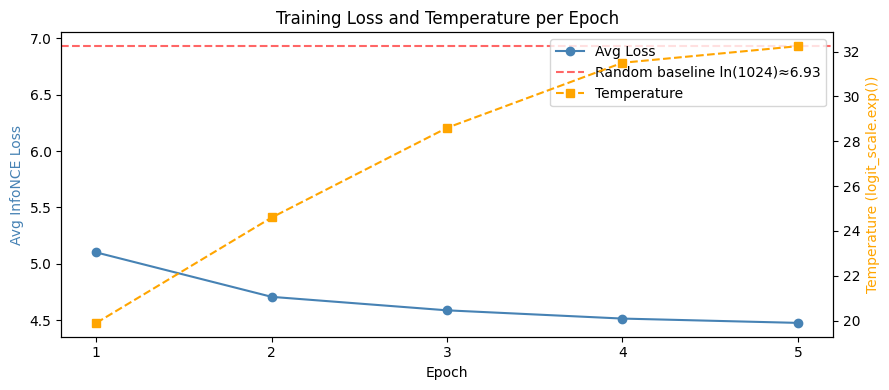

In [ ]:
import matplotlib.pyplot as plt

epochs      = [1, 2, 3, 4, 5]
avg_losses  = [5.1004, 4.7062, 4.5866, 4.5135, 4.4752]

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(epochs, avg_losses, marker='o', color='steelblue', label='Avg Loss')
ax1.axhline(y=6.931, color='red', linestyle='--', alpha=0.6, label='Random baseline ln(1024)≈6.93')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Avg InfoNCE Loss', color='steelblue')
ax1.set_xticks(epochs)

ax2 = ax1.twinx()
temps = [19.9, 24.6, 28.6, 31.5, 32.24]
ax2.plot(epochs, temps, marker='s', color='orange', linestyle='--', label='Temperature')
ax2.set_ylabel('Temperature (logit_scale.exp())', color='orange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.title('Training Loss and Temperature per Epoch')
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)

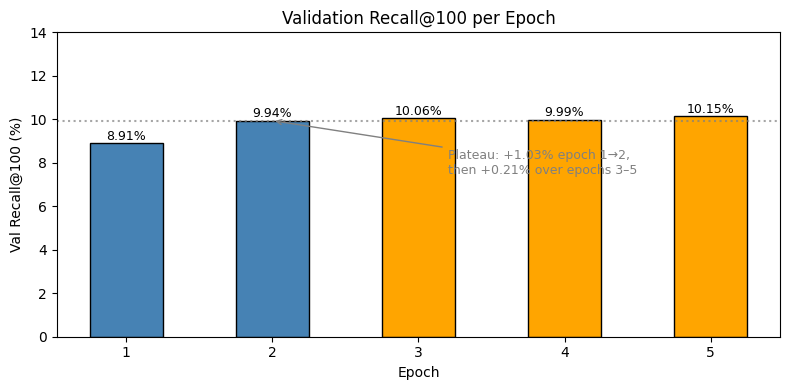

In [ ]:
epochs   = [1, 2, 3, 4, 5]
recalls  = [8.91, 9.94, 10.06, 9.99, 10.15]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(epochs, recalls, color=['steelblue','steelblue','orange','orange','orange'],
              edgecolor='k', width=0.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Recall@100 (%)')
ax.set_xticks(epochs); ax.set_ylim(0, 14)
ax.axhline(y=recalls[1], color='gray', linestyle=':', alpha=0.7)
ax.annotate('Plateau: +1.03% epoch 1→2,\nthen +0.21% over epochs 3–5',
            xy=(2, 9.94), xytext=(3.2, 7.5),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')
for bar, r in zip(bars, recalls):
    ax.text(bar.get_x() + bar.get_width()/2, r + 0.15, f'{r:.2f}%', ha='center', fontsize=9)
plt.title('Validation Recall@100 per Epoch')
plt.tight_layout()
plt.savefig('recall_curve.png', dpi=150)

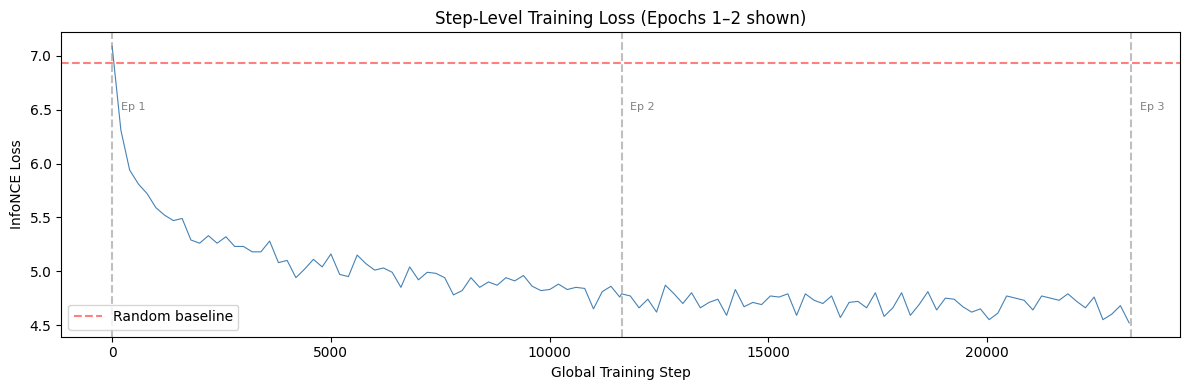

In [ ]:
ep1_steps  = list(range(0, 11642, 200))
ep1_losses = [7.09,6.31,5.94,5.81,5.72,5.59,5.52,5.47,5.49,5.29,5.26,5.33,5.26,5.32,5.23,5.23,5.18,5.18,5.28,5.08,5.10,4.94,5.02,5.11,5.04,5.16,4.97,4.95,5.15,5.07,5.01,5.03,4.99,4.85,5.04,4.92,4.99,4.98,4.94,4.78,4.82,4.94,4.85,4.90,4.87,4.94,4.91,4.96,4.86,4.82,4.83,4.88,4.83,4.85,4.84,4.65,4.81,4.86,4.76]
ep2_start  = 11642
ep2_steps  = [ep2_start + s for s in range(0, 11642, 200)]
ep2_losses = [4.79,4.77,4.66,4.74,4.62,4.87,4.79,4.70,4.80,4.66,4.71,4.74,4.59,4.83,4.67,4.71,4.69,4.77,4.76,4.79,4.59,4.79,4.73,4.70,4.77,4.57,4.71,4.72,4.66,4.80,4.58,4.66,4.80,4.59,4.69,4.81,4.64,4.75,4.74,4.67,4.62,4.65,4.55,4.61,4.77,4.75,4.73,4.64,4.77,4.75,4.73,4.79,4.72,4.66,4.76,4.55,4.60,4.68,4.52]
all_steps  = ep1_steps + ep2_steps
all_losses = ep1_losses + ep2_losses

plt.figure(figsize=(12, 4))
plt.plot(all_steps, all_losses, linewidth=0.8, color='steelblue')
for ep, x in enumerate([0, 11642, 23284], start=1):
    plt.axvline(x=x, color='gray', linestyle='--', alpha=0.5)
    plt.text(x + 200, 6.5, f'Ep {ep}', color='gray', fontsize=8)
plt.axhline(y=6.931, color='red', linestyle='--', alpha=0.5, label='Random baseline')
plt.xlabel('Global Training Step'); plt.ylabel('InfoNCE Loss')
plt.title('Step-Level Training Loss (Epochs 1–2 shown)')
plt.legend(); plt.tight_layout()
plt.savefig('loss_steps.png', dpi=150)

## 5. Load Weights

In [ ]:
# update filename to whichever checkpoint you want to evaluate
WEIGHT_FILE = 'two_tower_ep5_loss4.4752.pt'
load_path   = os.path.join(WEIGHTS_FOLDER, WEIGHT_FILE)

model = TwoTower(text_embeddings).to(device)
state_dict = torch.load(load_path, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()
print(f'Loaded: {load_path}')

## 6. Evaluation — FAISS Index & Recall@K

**Active articles** = those sold within 6 weeks of the training cutoff (Sep 8, 2020).
Only active articles are added to the FAISS catalog — ARCHIVED items are excluded at inference time.
All item embeddings are computed by the ItemTower in a single batched pass before building the index.

In [ ]:
import faiss


@torch.no_grad()
def compute_item_embeddings(model, articles_df, text_embeddings, device, batch_size=512):
    '''
    Run ItemTower over all rows in articles_df.
    Pass a filtered articles_df (active articles only) to build the FAISS catalog.
    Returns:
        item_embs    — np.float32 (N, FINAL_DIM), L2-normalized
        item_ids_arr — np.ndarray (N,) of article_id integers (H&M original IDs)
    '''
    model.eval()
    df, all_embs = articles_df.reset_index(drop=True), []

    for start in range(0, len(df), batch_size):
        batch    = df.iloc[start: start + batch_size]
        txt_idxs = batch['article_encoded'].values - 1
        feats = {
            'product_type_no':         torch.tensor(batch['product_type_no'].values,         dtype=torch.long).to(device),
            'graphical_appearance_no': torch.tensor(batch['graphical_appearance_no'].values, dtype=torch.long).to(device),
            'colour_group_code':       torch.tensor(batch['colour_group_code'].values,       dtype=torch.long).to(device),
            'index_group_no':          torch.tensor(batch['index_group_no'].values,          dtype=torch.long).to(device),
            'section_no':              torch.tensor(batch['section_no'].values,              dtype=torch.long).to(device),
            'garment_group_no':        torch.tensor(batch['garment_group_no'].values,        dtype=torch.long).to(device),
            'text_embedding':          torch.tensor(text_embeddings[txt_idxs],               dtype=torch.float32).to(device),
        }
        all_embs.append(model.item_tower(feats).cpu().numpy())

    return np.vstack(all_embs), df['article_id'].values


In [ ]:
@torch.no_grad()
def compute_user_embeddings(model, users, hist_grouped, cust_static, art_cat_lkp,
                             device, seq_len=SEQ_LEN, batch_size=256):
    '''
    Compute embeddings for a list of users in batches.
    hist_grouped: train_df sorted by t_dat and grouped by customer_id (built once).
    Returns: np.float32 (N_users, FINAL_DIM)
    '''
    model.eval()
    all_embs = []
    for start in tqdm(range(0, len(users), batch_size), desc='User embeddings'):
        batch = users[start : start + batch_size]
        B, T  = len(batch), seq_len
        seq_art    = np.zeros((B, T), dtype=np.int64)
        seq_price  = np.zeros((B, T), dtype=np.int64)
        seq_ch     = np.zeros((B, T), dtype=np.float32)
        seq_delta  = np.zeros((B, T), dtype=np.int64)
        seq_sin    = np.zeros((B, T), dtype=np.float32)
        seq_cos    = np.zeros((B, T), dtype=np.float32)
        seq_ptype  = np.zeros((B, T), dtype=np.int64)
        seq_app    = np.zeros((B, T), dtype=np.int64)
        seq_colour = np.zeros((B, T), dtype=np.int64)
        seq_idx    = np.zeros((B, T), dtype=np.int64)
        seq_sec    = np.zeros((B, T), dtype=np.int64)
        seq_gar    = np.zeros((B, T), dtype=np.int64)
        pad_mask   = np.ones((B, T), dtype=bool)
        club       = np.full(B, 3, dtype=np.int64)
        fn_freq    = np.full(B, 3, dtype=np.int64)
        age_arr    = np.full(B, 10, dtype=np.int64)
        fn_arr     = np.zeros(B, dtype=np.float32)
        act_arr    = np.zeros(B, dtype=np.float32)
        for i, cust_id in enumerate(batch):
            try:
                hist = hist_grouped.get_group(cust_id)
            except KeyError:
                continue
            n   = min(len(hist), T)
            h   = hist.iloc[-n:]
            enc = h['article_encoded'].values.astype(np.int64)
            seq_art[i, -n:]    = enc
            seq_price[i, -n:]  = h['price_bucket'].values
            seq_ch[i, -n:]     = h['sales_channel_id'].values.astype(np.float32)
            seq_delta[i, -n:]  = h['time_delta_bucket'].values
            seq_sin[i, -n:]    = h['season_sin'].values.astype(np.float32)
            seq_cos[i, -n:]    = h['season_cos'].values.astype(np.float32)
            seq_ptype[i, -n:]  = art_cat_lkp['product_type_no'][enc - 1]
            seq_app[i, -n:]    = art_cat_lkp['graphical_appearance_no'][enc - 1]
            seq_colour[i, -n:] = art_cat_lkp['colour_group_code'][enc - 1]
            seq_idx[i, -n:]    = art_cat_lkp['index_group_no'][enc - 1]
            seq_sec[i, -n:]    = art_cat_lkp['section_no'][enc - 1]
            seq_gar[i, -n:]    = art_cat_lkp['garment_group_no'][enc - 1]
            pad_mask[i, -n:]   = False
            cs           = cust_static.get(cust_id, {})
            club[i]      = cs.get('club_member_status', 3)
            fn_freq[i]   = cs.get('fashion_news_frequency', 3)
            age_arr[i]   = cs.get('age_bucket', 10)
            fn_arr[i]    = float(cs.get('FN', 0.0))
            act_arr[i]   = float(cs.get('Active', 0.0))
        uf = {
            'club_member_status':     torch.from_numpy(club).to(device),
            'fashion_news_frequency': torch.from_numpy(fn_freq).to(device),
            'age_bucket':             torch.from_numpy(age_arr).to(device),
            'FN':                     torch.from_numpy(fn_arr).to(device),
            'Active':                 torch.from_numpy(act_arr).to(device),
        }
        sf = {
            'article_encoded':         torch.from_numpy(seq_art).to(device),
            'price_bucket':            torch.from_numpy(seq_price).to(device),
            'sales_channel_id':        torch.from_numpy(seq_ch).to(device),
            'time_delta_bucket':       torch.from_numpy(seq_delta).to(device),
            'season_sin':              torch.from_numpy(seq_sin).to(device),
            'season_cos':              torch.from_numpy(seq_cos).to(device),
            'product_type_no':         torch.from_numpy(seq_ptype).to(device),
            'graphical_appearance_no': torch.from_numpy(seq_app).to(device),
            'colour_group_code':       torch.from_numpy(seq_colour).to(device),
            'index_group_no':          torch.from_numpy(seq_idx).to(device),
            'section_no':              torch.from_numpy(seq_sec).to(device),
            'garment_group_no':        torch.from_numpy(seq_gar).to(device),
        }
        pm  = torch.from_numpy(pad_mask).to(device)
        emb = model.user_tower(uf, sf, pm).cpu().numpy()
        all_embs.append(emb)
    return np.vstack(all_embs).astype(np.float32)


In [ ]:
def evaluate_all_recalls(user_embs, users, gt_grouped, faiss_index, item_ids_arr, ks):
    '''
    Compute Recall@K for every K in ks from pre-computed user embeddings.
    Single FAISS search for max(ks); recall for smaller K reuses the same result.
    '''
    max_k = max(ks)
    print(f'FAISS search: {len(users):,} users x top-{max_k}...')
    _, all_idxs = faiss_index.search(user_embs, max_k)  # (N_users, max_k)
    results = {}
    for k in ks:
        recalls = []
        for i, cust_id in enumerate(users):
            gt = gt_grouped.get(cust_id, set())
            if not gt:
                continue
            retrieved = set(item_ids_arr[all_idxs[i, :k]])
            recalls.append(len(retrieved & gt) / len(gt))
        results[k] = float(np.mean(recalls))
        print(f'Recall@{k}: {results[k]:.4f}  ({len(recalls)} users)')
    return results


In [ ]:
# pre-build O(1) customer lookup
cust_static = customers_df.set_index('customer_id')[
    ['customer_encoded', 'FN', 'Active',
     'club_member_status', 'fashion_news_frequency', 'age_bucket']
].to_dict(orient='index')

# pre-build article categorical lookup arrays, indexed by article_encoded - 1
_art_s = articles_df.sort_values('article_encoded').reset_index(drop=True)
art_cat_lkp = {
    'product_type_no':         _art_s['product_type_no'].values.astype(np.int64),
    'graphical_appearance_no': _art_s['graphical_appearance_no'].values.astype(np.int64),
    'colour_group_code':       _art_s['colour_group_code'].values.astype(np.int64),
    'index_group_no':          _art_s['index_group_no'].values.astype(np.int64),
    'section_no':              _art_s['section_no'].values.astype(np.int64),
    'garment_group_no':        _art_s['garment_group_no'].values.astype(np.int64),
}

# active articles = sold within 6 weeks of the Sep 8 training cutoff
SIX_WEEKS_BEFORE_CUTOFF = pd.Timestamp('2020-07-28')
active_ids = set(train_df[train_df['t_dat'] >= SIX_WEEKS_BEFORE_CUTOFF]['article_id'].unique())
active_articles_df = articles_df[articles_df['article_id'].isin(active_ids)].reset_index(drop=True)
print(f'Active articles: {len(active_articles_df):,} / {len(articles_df):,} total')

# item embeddings
print('Computing item embeddings...')
item_embs, item_ids_arr = compute_item_embeddings(model, active_articles_df, text_embeddings, device)

# FAISS index
faiss_index = faiss.IndexFlatIP(FINAL_DIM)
faiss_index.add(item_embs)
print(f'FAISS index: {faiss_index.ntotal:,} items')

# pre-group history once — avoids scanning 12.5M rows per user
users        = tt_test_df['customer_id'].unique()
hist_grouped = train_df.sort_values('t_dat').groupby('customer_id')
gt_grouped   = tt_test_df.groupby('customer_id')['article_id'].apply(set).to_dict()

# compute all user embeddings in batches of 256
print(f'Computing user embeddings for {len(users):,} test users...')
user_embs = compute_user_embeddings(model, users, hist_grouped, cust_static, art_cat_lkp, device)
print(f'User embeddings: {user_embs.shape}')


Active articles: 27,368 / 105,542 total
Computing item embeddings...
FAISS index: 27,368 items
Computing user embeddings for 20,312 test users...


User embeddings:   0%|          | 0/80 [00:00<?, ?it/s]

User embeddings: (20312, 512)


FAISS search: 20,312 users x top-1000...
Recall@10: 0.0307  (20312 users)
Recall@50: 0.0676  (20312 users)
Recall@100: 0.0968  (20312 users)
Recall@200: 0.1395  (20312 users)
Recall@500: 0.2237  (20312 users)
Recall@1000: 0.3094  (20312 users)


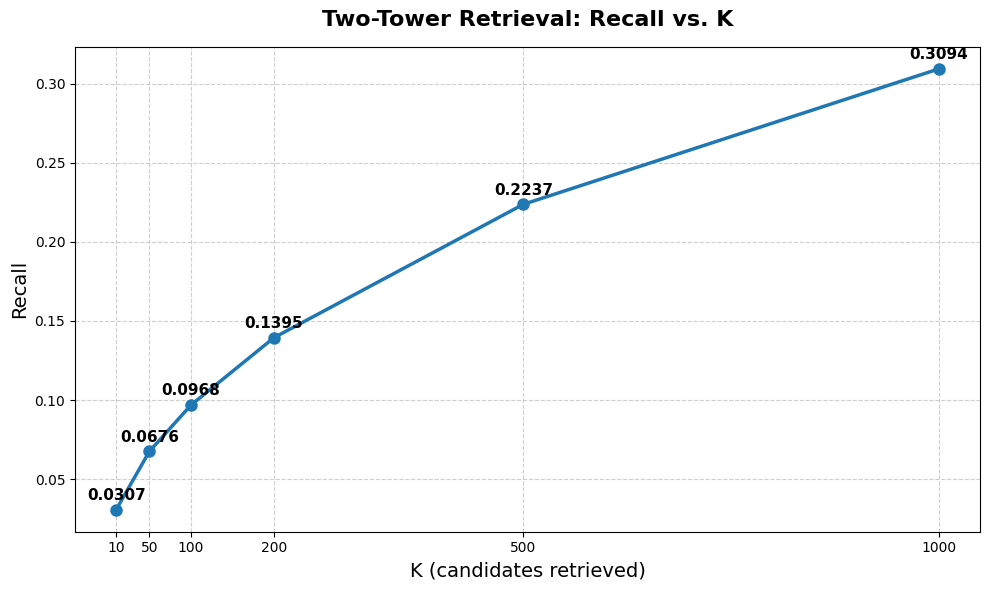

In [ ]:
k_values      = [10, 50, 100, 200, 500, 1000]
recall_results = evaluate_all_recalls(user_embs, users, gt_grouped, faiss_index, item_ids_arr, k_values)
recall_scores  = [recall_results[k] for k in k_values]

plt.figure(figsize=(10, 6))
plt.plot(k_values, recall_scores, marker='o', linewidth=2.5, markersize=8, color='#1f77b4')
for x, y in zip(k_values, recall_scores):
    plt.text(x, y + max(recall_scores) * 0.02, f'{y:.4f}',
             ha='center', fontsize=11, fontweight='bold')
plt.title('Two-Tower Retrieval: Recall vs. K', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('K (candidates retrieved)', fontsize=14)
plt.ylabel('Recall', fontsize=14)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
